# SHRED on ME4OH full-field OFAM3 SST data

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler

import models  # https://github.com/Jan-Williams/pyshred/blob/main/models.py 
from Data.preprocess_sst_ofam3_shred import create_shred_sequences, load_files, split_ordered_data
from Data.preprocess_sst_ofam3_shred import NA_DATA_PATH
from plotting_functions import plot_sst_map, plot_compare_NA_sst_recon_truth

np.random.seed(42)

# Example visualisation

In [ ]:
date = '1979-01-04'
df = pd.read_csv(f"{NA_DATA_PATH}{date}.csv")
# df['Date'] = pd.to_datetime('1979-01-04')

In [ ]:
df

In [ ]:
plot_sst_map(df, date, min(df.SST), max(df.SST), basin='NA')

# SHRED

In [2]:
num_sensors = 5
lags = 52

In [3]:
# Load and reformat data
data, dates, lats, longs = load_files()

Loading data: 100%|██████████| 1879/1879 [00:22<00:00, 85.22it/s] 


In [4]:
print("Preprocessing data...")
train_data, val_data, test_data, train_dates, val_dates, test_dates = split_ordered_data(data, dates)

# Normalise data
sc = MinMaxScaler()
sc = sc.fit(train_data)  # Computes min and max from training data only (prevent data leakage)
train_transformed = sc.transform(train_data)  
val_transformed = sc.transform(val_data)
test_transformed = sc.transform(test_data)

# Build sequences
sensor_locations = np.random.choice(data.shape[1], size=num_sensors, replace=False)
print(f"Sensor location indexes will be: {sensor_locations}")

train_dataset = create_shred_sequences(train_transformed, sensor_locations, num_sensors=num_sensors, lags=lags)
val_dataset = create_shred_sequences(val_transformed, sensor_locations, num_sensors=num_sensors, lags=lags)
test_dataset = create_shred_sequences(test_transformed, sensor_locations, num_sensors=num_sensors, lags=lags)


Preprocessing data...
Sensor location indexes will be: [20184 34842 53041 35074  4053]


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
shred = models.SHRED(num_sensors, len(lats), hidden_size=64, hidden_layers=2, l1=350, l2=400, dropout=0.1).to(device)
validation_errors = models.fit(shred, train_dataset, val_dataset, batch_size=64, num_epochs=1000, lr=1e-3, verbose=True, patience=5)

In [ ]:
test_recons = sc.inverse_transform(shred(test_dataset.X).detach().cpu().numpy())
test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
print('Test Reconstruction Error: ')
print(np.linalg.norm(test_recons - test_ground_truth) / np.linalg.norm(test_ground_truth))

In [ ]:
np.save("recons", test_recons)
np.save("truth", test_ground_truth)

In [5]:
test_recons = np.load("recons.npy")
test_ground_truth = np.load("truth.npy")

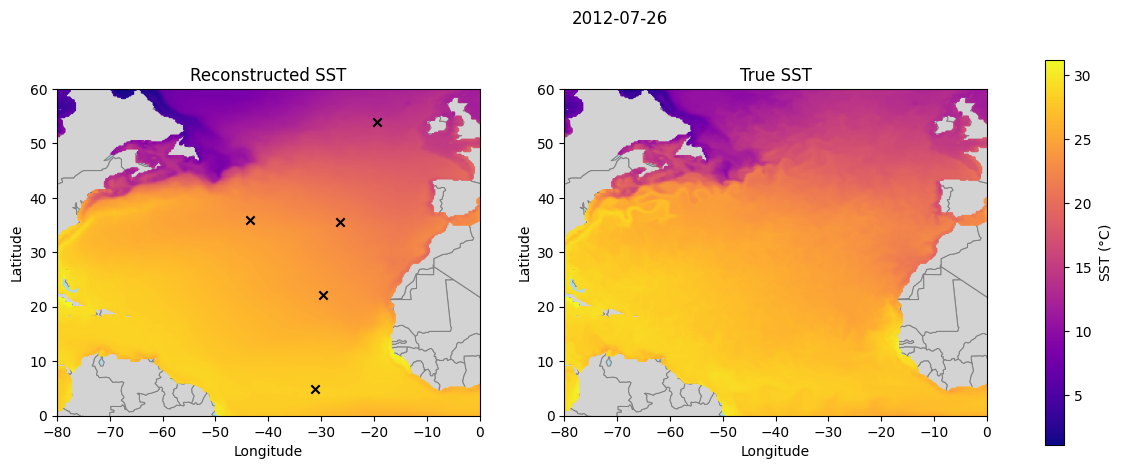

In [6]:
for i in np.random.choice(range(len(test_recons)), 1):
    recon_df = pd.DataFrame({
        "Latitude": lats,
        "Longitude": longs,
        "SST": test_recons[i]
    })
    date = str(test_dates[i].date())
    true_df = pd.read_csv(f"{NA_DATA_PATH}{date}.csv")
    plot_compare_NA_sst_recon_truth(recon_df, true_df, title=date, sensor_coords=(longs[sensor_locations], lats[sensor_locations]))

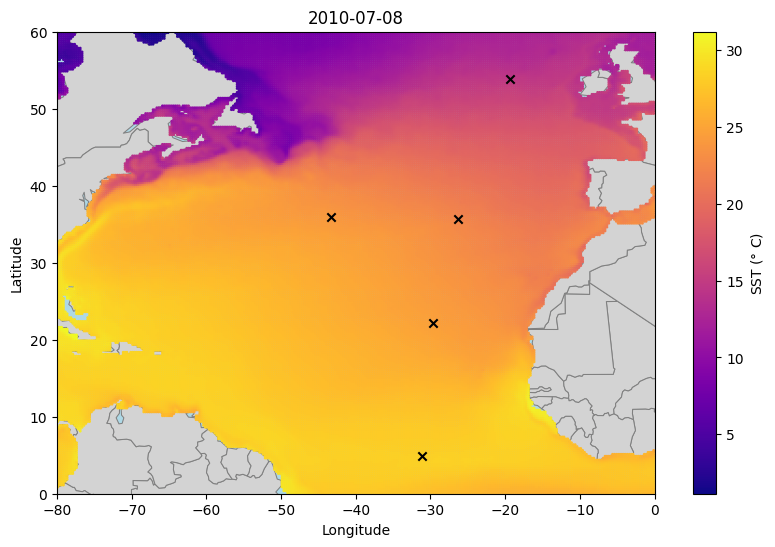

In [7]:
plot_sst_map(recon_df, str(test_dates[0].date()), min_sst=min(recon_df.SST), max_sst=max(recon_df.SST), basin='NA', sensor_coords=(longs[sensor_locations], lats[sensor_locations]))

In [ ]:

# plot_sst_map(true_df, date, min(true_df.SST), max(true_df.SST), basin='NA')